# LINDA VASQUEZ Proyecto K-vecinos más Cercanos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
datos = pd.read_csv(url, sep=";")

In [3]:
def agrupar_calidad(calidad):
    if calidad <= 4:
        return 0  # Calidad baja
    elif calidad <= 6:
        return 1  # Calidad media
    else:
        return 2  # Calidad alta

datos['etiqueta'] = datos['quality'].apply(agrupar_calidad)

## División de los datos

In [4]:
x = datos.drop(["etiqueta", "quality"], axis=1)
y = datos["etiqueta"]

# (80/20)
x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
escalador = StandardScaler()
x_entrenamiento_escalado = escalador.fit_transform(x_entrenamiento)
x_prueba_escalada = escalador.transform(x_prueba)

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(x_entrenamiento_escalado, y_entrenamiento)

# primeras predicciones
predicciones = modelo_knn.predict(x_prueba_escalada)

print("Precisión inicial:", accuracy_score(y_prueba, predicciones))
print("\nMatriz de confusión:\n", confusion_matrix(y_prueba, predicciones))
print("\nReporte completo:\n", classification_report(y_prueba, predicciones))

Precisión inicial: 0.84375

Matriz de confusión:
 [[  0  11   0]
 [  1 250  11]
 [  0  27  20]]

Reporte completo:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



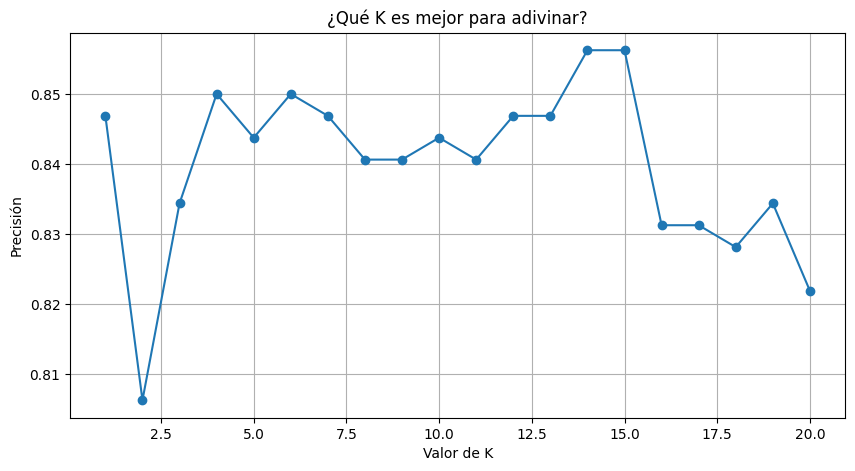


¡El mejor valor de k que encontramos es: 14!


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [6]:
# Buscar el mejor valor para k (probando del 1 al 20)
valores_k = range(1, 21)
lista_precisiones = []

for k in valores_k:
    modelo_prueba = KNeighborsClassifier(n_neighbors=k)
    modelo_prueba.fit(x_entrenamiento_escalado, y_entrenamiento)
    prediccion_k = modelo_prueba.predict(x_prueba_escalada)
    lista_precisiones.append(accuracy_score(y_prueba, prediccion_k))

plt.figure(figsize=(10, 5))
plt.plot(valores_k, lista_precisiones, marker='o')
plt.title("¿Qué K es mejor para adivinar?")
plt.xlabel("Valor de K")
plt.ylabel("Precisión")
plt.grid(True)
plt.show()

mejor_k = valores_k[lista_precisiones.index(max(lista_precisiones))]
print(f"\n¡El mejor valor de k que encontramos es: {mejor_k}!")

modelo_final = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_final.fit(x_entrenamiento_escalado, y_entrenamiento)

## Función para jugar al sommelier

In [8]:
def predecir_calidad_vino(caracteristicas_vino):
    vino_escalado = escalador.transform([caracteristicas_vino])
    resultado = modelo_final.predict(vino_escalado)[0]
    
    if resultado == 0:
        return "Este vino probablemente sea de baja calidad"
    elif resultado == 1:
        return "Este vino probablemente sea de calidad media"
    else:
        return "Este vino probablemente sea de alta calidad"

# Prueba
respuesta = predecir_calidad_vino([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nPredicción de nuestro vino de prueba:", respuesta)


Predicción de nuestro vino de prueba: Este vino probablemente sea de calidad media


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
